In [ ]:
# IMPORTANT: This cell defines the 'model' object. Please ensure it is executed before any cells that use 'model'.

# deep learning
import torch
import torch.nn as nn

# simple neuron
model = nn.Linear(1, 1)

x = torch.tensor([[2.0]])
y = model(x)

print(y)

tensor([[1.0982]], grad_fn=<AddmmBackward0>)


### Training a simple PyTorch Linear Model

Let's generate some synthetic data for training a linear regression model. We'll define a simple linear function with some noise, then train our `nn.Linear` model to learn these parameters.

Starting training...
Epoch [10/100], Loss: 1822.5618
Epoch [20/100], Loss: 10075.4209
Epoch [30/100], Loss: 55769.7305
Epoch [40/100], Loss: 308768.8750
Epoch [50/100], Loss: 1709576.1250
Epoch [60/100], Loss: 9465565.0000
Epoch [70/100], Loss: 52408760.0000
Epoch [80/100], Loss: 290175808.0000
Epoch [90/100], Loss: 1606639744.0000
Epoch [100/100], Loss: 8895621120.0000
Training finished!


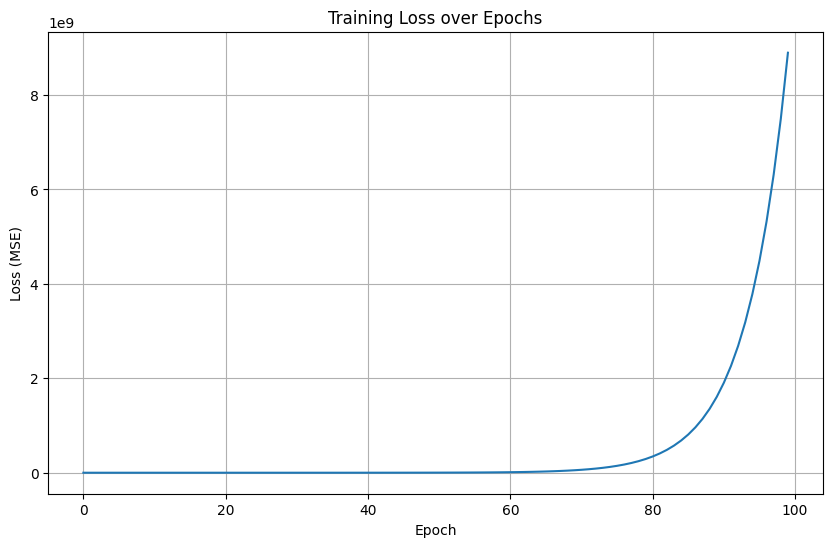

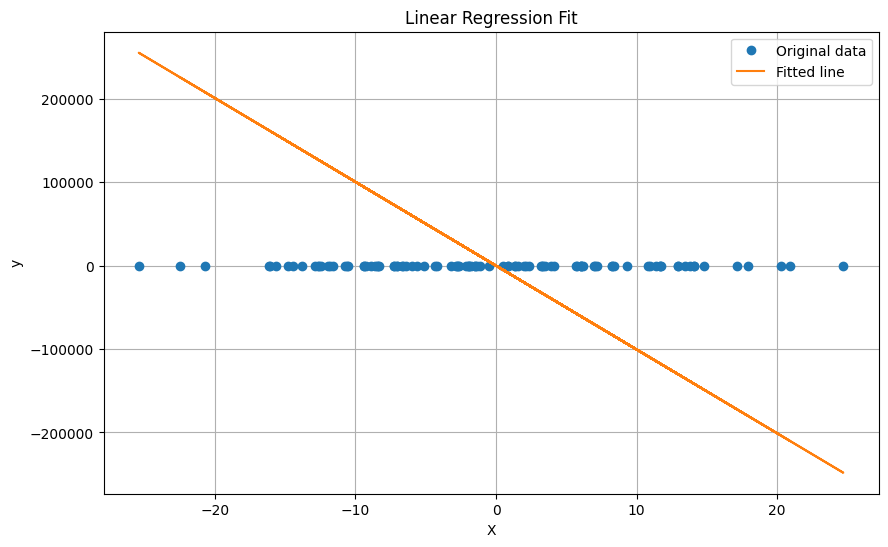


Learned parameters (weight, bias):
weight: -10050.0254
bias: 59.3613


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Generate synthetic data
# We want to learn y = 2x + 1 + noise
X_train = torch.randn(100, 1) * 10
y_train = 2 * X_train + 1 + torch.randn(100, 1) * 2

# 2. Define the model (already done in cell N21EUjprbrs- but redefined for clarity)
# model = nn.Linear(1, 1)

# Assuming 'model' from cell N21EUjprbrs- is the one we want to train
# If it was executed, it already has some random weights. We'll use it.

# 3. Define Loss Function and Optimizer
criterion = nn.MSELoss() # Mean Squared Error Loss for regression
optimizer = optim.SGD(model.parameters(), lr=0.01) # Stochastic Gradient Descent optimizer

# 4. Training Loop
num_epochs = 100
losses = []

print("Starting training...")
for epoch in range(num_epochs):
    # Forward pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    # Backward and optimize
    optimizer.zero_grad() # Clear gradients
    loss.backward()       # Compute gradients
    optimizer.step()      # Update model parameters

    losses.append(loss.item())

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

print("Training finished!")

# 5. Plotting results
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.grid(True)
plt.show()

# 6. Evaluate the trained model
predicted = model(X_train).detach().numpy()
plt.figure(figsize=(10, 6))
plt.plot(X_train.numpy(), y_train.numpy(), 'o', label='Original data')
plt.plot(X_train.numpy(), predicted, label='Fitted line')
plt.title('Linear Regression Fit')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

print("\nLearned parameters (weight, bias):")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"{name}: {param.data.item():.4f}")


In [ ]:
import tensorflow as tf

model = tf.keras.layers.Dense(1)

x = tf.constant([[2.0]])
y = model(x)

print(y)

tf.Tensor([[-3.427134]], shape=(1, 1), dtype=float32)
